In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [44]:
df = pd.read_csv('../experiments_real/results/mnist/seed1.csv')

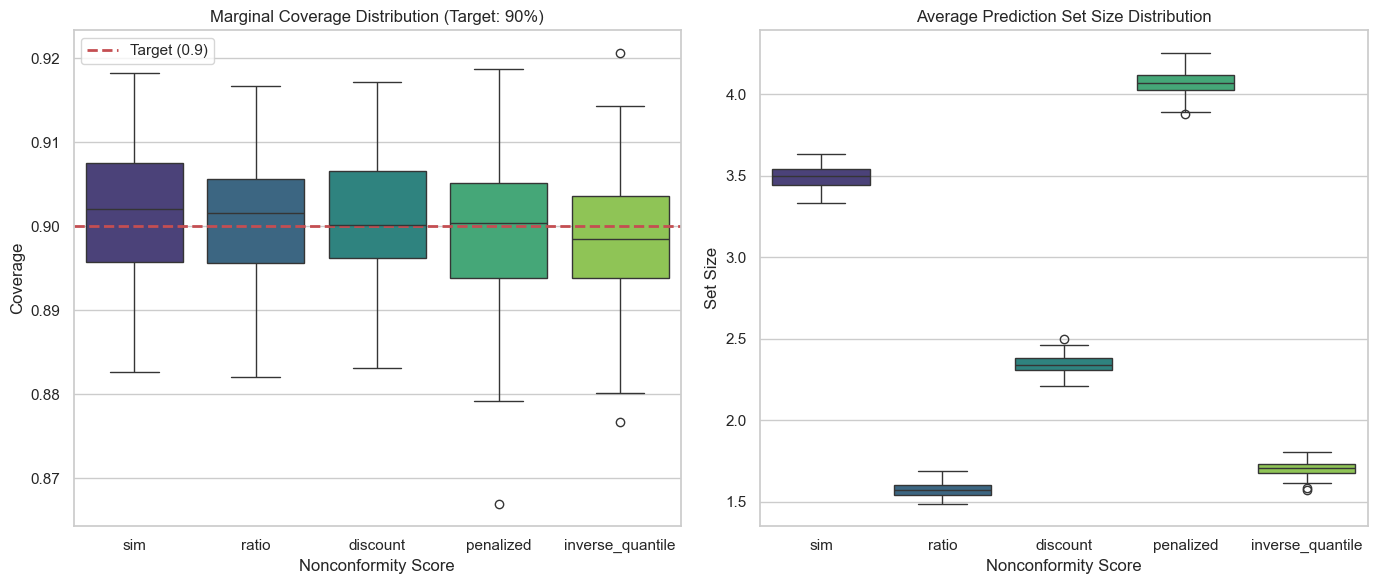

In [48]:
# ==========================================
# Visualization 1: Coverage and Size (Boxplots)
# ==========================================
# Filter: Experiment = set_valued, Marginal = True
df_sets = df[(df['exp'] == 'set_valued') & (df['marginal'] == True)]

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1A: Marginal Coverage
# FIX: Added hue='score_type' and legend=False
sns.boxplot(
    x='score_type', 
    y='marginal_cov', 
    hue='score_type',  # <--- Fixes warning
    data=df_sets, 
    ax=axes1[0], 
    palette='viridis',
    legend=False       # <--- Hides redundant legend
)
axes1[0].axhline(y=0.9, color='r', linestyle='--', linewidth=2, label='Target (0.9)')
axes1[0].set_title('Marginal Coverage Distribution (Target: 90%)')
axes1[0].set_ylabel('Coverage')
axes1[0].set_xlabel('Nonconformity Score')
# We add a custom legend just for the target line, not the boxplot colors
axes1[0].legend()

# Plot 1B: Average Set Size
# FIX: Added hue='score_type' and legend=False
sns.boxplot(
    x='score_type', 
    y='avg_size', 
    hue='score_type',  # <--- Fixes warning
    data=df_sets, 
    ax=axes1[1], 
    palette='viridis',
    legend=False       # <--- Hides redundant legend
)
axes1[1].set_title('Average Prediction Set Size Distribution')
axes1[1].set_ylabel('Set Size')
axes1[1].set_xlabel('Nonconformity Score')

plt.tight_layout()
plt.show()

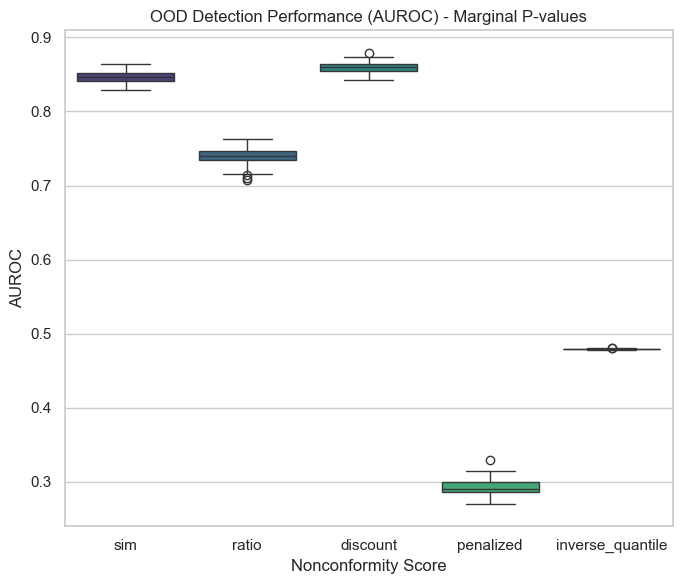

In [55]:
df_ood_marginal = df[(df['exp'] == 'ood') & (df['marginal'] == True)]

plt.figure(figsize=(7, 6))

# Create Boxplot
# Note: We set hue='score_type' to fix the Seaborn warning, 
# and dodge=False to keep boxes centered on the ticks.
ax = sns.boxplot(
    x='score_type', 
    y='auroc', 
    hue='score_type', 
    data=df_ood_marginal, 
    palette='viridis',
    dodge=False 
)

# Manually remove the redundant legend created by 'hue'
if ax.legend_:
    ax.legend_.remove()

plt.title('OOD Detection Performance (AUROC) - Marginal P-values')
plt.ylabel('AUROC')
plt.xlabel('Nonconformity Score')
plt.tight_layout()
plt.show()

C:\Users\liang\AppData\Local\Temp\ipykernel_86720\177903931.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Variant')


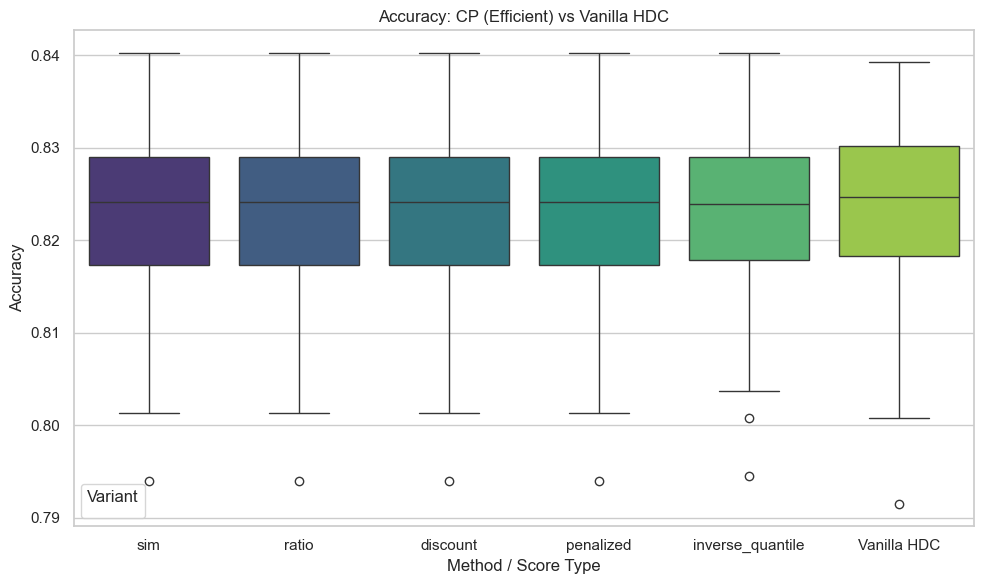

In [58]:
df_acc = df[df['exp'] == 'accuracy']

# 3. Filter for desired methods: 'cp_efficient' and 'vanilla_hdc'
# (Explicitly ignoring 'cp_accurate' as requested)
df_plot = df_acc[df_acc['method'].isin(['cp_efficient', 'vanilla_hdc'])].copy()

# 4. Create a unified label for x-axis and hue
# - Vanilla rows get the label "Vanilla HDC"
# - CP Efficient rows get their specific "score_type" (sim, ratio, etc.)
df_plot['Plot_Label'] = df_plot.apply(
    lambda row: 'Vanilla HDC' if row['method'] == 'vanilla_hdc' else row['score_type'], 
    axis=1
)

# 5. Plot
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10, 6))

# Using Plot_Label for both x and hue ensures:
# - They are plotted side-by-side
# - They have distinct colors in the legend
# - Vanilla HDC appears as just one single box/category
sns.boxplot(
    x='Plot_Label', 
    y='accuracy', 
    hue='Plot_Label', 
    data=df_plot, 
    palette='viridis',
    dodge=False 
)

plt.title('Accuracy: CP (Efficient) vs Vanilla HDC')
plt.ylabel('Accuracy')
plt.xlabel('Method / Score Type')
plt.legend(title='Variant')

plt.tight_layout()
plt.show()